# TP2 - Métodos No Supervisados usando la EPH
### Taller de Programación (UBA) 2026 - Grupo 8: *Informal self-employed*

Continuación del TP1. Partimos de la base `self_emp` ya limpia, que contiene a los
trabajadores independientes (patrones, cuentapropistas y familiares sin remuneración,
excluyendo el sector público) del 4T2024 y 4T2025, con la variable `informal`
construida según Maurizio & Monsalvo y las dummies del TP1.


In [3]:
import pandas as pd
import numpy as np

self_emp = pd.read_parquet('bases/self_emp.parquet')
print("Dimensiones:", self_emp.shape)
self_emp.head()

Dimensiones: (11595, 45)


,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,PONDERA,CH04,CH06,CH07,CH08,NIVEL_ED,...,asalariado,fam_sin_remun,sector_privado,sector_informal,subocupado,nivel_ed_ord,P21_real,P47T_real,informal,grupo
27,TQRMNORSVHKLKTCDEGJBF00869911,2024,4,1,541,2,66,3.0,1.0,6,...,0,0,1.0,1.0,0.0,6,1.182696e+06,1.971159e+06,0.0,Formal
31,TQRMNOTTRHKOKTCDEFJAH00869619,2024,4,1,350,1,43,1.0,4.0,5,...,0,0,1.0,1.0,0.0,5,7.884637e+05,7.884637e+05,1.0,Informal
35,TQRMNOQSTHKNKUCDEFJAH00869632,2024,4,1,203,2,53,2.0,4.0,3,...,0,0,1.0,1.0,0.0,3,2.891034e+05,4.467961e+05,1.0,Informal
44,TQRMNOSXRHLMLNCDEHIBB00853817,2024,4,1,121,1,60,2.0,1.0,4,...,0,0,1.0,1.0,0.0,4,3.942319e+05,7.227584e+05,1.0,Informal
63,TQRMNORYYHKMKUCDEGJBF00870253,2024,4,1,670,1,47,1.0,4.0,4,...,0,0,1.0,1.0,1.0,4,2.628212e+05,2.628212e+05,1.0,Informal


In [4]:
print(self_emp['ANO4'].value_counts().sort_index())
print(self_emp['informal'].value_counts(dropna=False))

ANO4
2024    5840
2025    5755
Name: count, dtype: int64
informal
1.0    9388
0.0    2154
NaN      53
Name: count, dtype: int64


In [5]:
print(self_emp['PP3E_TOT'].describe())
print(self_emp['PP3F_TOT'].describe())

count    11566.000000
mean        35.818001
std         18.690697
min          0.000000
25%         20.000000
50%         36.000000
75%         48.000000
max        126.000000
Name: PP3E_TOT, dtype: float64
count    11595.000000
mean         1.119707
std         13.777483
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        999.000000
Name: PP3F_TOT, dtype: float64


In [6]:
print(self_emp.loc[self_emp['PP3F_TOT'] > 126, 'PP3F_TOT'].value_counts())

PP3F_TOT
999.0    2
Name: count, dtype: int64


#### 1.c) `horastrab` horas totales trabajadas

Suma de las horas en la ocupación principal (PP3E_TOT) y en otras ocupaciones (PP3F_TOT).
PP3F_TOT no había sido incluida en la limpieza del TP1, por lo que conserva el código
999 de no respuesta en 2 casos: se reemplaza por NaN antes de sumar. La suma resulta
NaN cuando falta alguno de los dos componentes, ya que en esos casos el total de horas
es desconocido.

In [7]:
# 999 es código de no respuesta en PP3F_TOT (2 casos): lo pasamos a NaN antes de sumar
self_emp['PP3F_TOT'] = self_emp['PP3F_TOT'].replace(999, np.nan)

self_emp['horastrab'] = self_emp['PP3E_TOT'] + self_emp['PP3F_TOT']

print(self_emp['horastrab'].describe())

count    11565.000000
mean        36.768526
std         19.165664
min          0.000000
25%         22.000000
50%         40.000000
75%         48.000000
max        131.000000
Name: horastrab, dtype: float64


#### 1.d) `nhogar` cantidad de miembros del hogar

Se calcula sobre la base completa y no sobre `self_emp`, porque esta última contiene
únicamente a los trabajadores independientes, contar filas ahí subestimaría el tamaño
del hogar. El hogar se identifica por CODUSU + NRO_HOGAR, y se agrega ANO4 porque la
EPH es un panel rotativo y una misma vivienda puede aparecer en ambos trimestres.

In [8]:
# nhogar se calcula sobre la base completa (self_emp solo tiene a los independientes)
df24 = pd.read_parquet('bases/df24.parquet')
df25 = pd.read_parquet('bases/df25.parquet')
completa = pd.concat([df24, df25], ignore_index=True)

# Cantidad de miembros por hogar, en cada año
tam_hogar = (completa
             .groupby(['CODUSU', 'NRO_HOGAR', 'ANO4'])['COMPONENTE']
             .count()
             .rename('nhogar')
             .reset_index())

# Lo pegamos a self_emp
self_emp = self_emp.merge(tam_hogar, on=['CODUSU', 'NRO_HOGAR', 'ANO4'], how='left')

print(self_emp['nhogar'].describe())
print("Sin correspondencia:", self_emp['nhogar'].isna().sum())

count    11595.000000
mean         3.458301
std          1.735597
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         19.000000
Name: nhogar, dtype: float64
Sin correspondencia: 0


La construcción de `nhogar` se validó contra la variable IX_TOT de la base de hogares
de la EPH, con coincidencia del 100% de los casos.

In [11]:
hog24 = pd.read_excel('bases/usu_hogar_T424.xlsx', usecols=['CODUSU','NRO_HOGAR','ANO4','IX_TOT'])
comp = tam_hogar.merge(hog24, on=['CODUSU','NRO_HOGAR','ANO4'], how='inner')
print("Coinciden:", (comp['nhogar'] == comp['IX_TOT']).mean())

Coinciden: 1.0


In [13]:
for v in ['CH12','CH13','CH14']:
    print(f"--- {v} ---")
    print(self_emp[v].value_counts(dropna=False).sort_index())
    print()

--- CH12 ---
CH12
0       22
1       11
2     1969
3      116
4     5418
5      164
6     1363
7     2376
8      148
9        3
99       5
Name: count, dtype: int64

--- CH13 ---
CH13
0      22
1    7472
2    4098
9       3
Name: count, dtype: int64

--- CH14 ---
CH14
0.0      208
1.0      573
2.0     1079
3.0     1100
4.0      610
5.0      248
6.0       99
7.0       16
8.0       28
9.0        6
98.0       4
99.0     130
NaN     7494
Name: count, dtype: int64



In [14]:
def calcular_educ(row):
    base = {1: 0, 2: 0, 3: 0, 4: 7, 5: 9, 6: 12, 7: 12, 8: 18}
    dur  = {1: 0, 2: 7, 3: 9, 4: 5, 5: 3, 6: 3,  7: 6,  8: 4}
    
    ch12, ch13, ch14 = row['CH12'], row['CH13'], row['CH14']
    
    if ch12 == 0 or ch12 == 9:          # nunca asistió / educación especial
        return 0
    if ch12 not in base:                # CH12 = 99 (Ns/Nr)
        return np.nan
    if ch13 == 1:                       # finalizó el nivel
        return base[ch12] + dur[ch12]
    if ch13 == 2:                       # no lo finalizó
        if pd.isna(ch14) or ch14 >= 98: # Ns/Nr o educación especial
            return np.nan
        return min(base[ch12] + ch14, base[ch12] + dur[ch12])
    return np.nan                       # CH13 = 9

self_emp['educ'] = self_emp.apply(calcular_educ, axis=1)

print(self_emp['educ'].describe())
print("Faltantes:", self_emp['educ'].isna().sum())

count    11462.000000
mean        11.910225
std          3.800962
min          0.000000
25%          9.000000
50%         12.000000
75%         15.000000
max         22.000000
Name: educ, dtype: float64
Faltantes: 133


In [15]:
pd.crosstab(self_emp['CH12'], self_emp['educ'], dropna=False)

educ,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,NaN
CH12,,,,,,,,,,,,,,,,,,,,,
0,22,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,11,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,8,28,46,87,80,65,55,1573,0,0,...,0,0,0,0,0,0,0,0,0,27
3,0,1,2,1,3,0,22,16,28,40,...,0,0,0,0,0,0,0,0,0,3
4,0,0,0,0,0,0,0,54,267,529,...,0,0,0,0,0,0,0,0,0,56
5,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,0,3
6,0,0,0,0,0,0,0,0,0,0,...,206,998,0,0,0,0,0,0,0,18
7,0,0,0,0,0,0,0,0,0,0,...,269,293,174,51,1305,0,0,0,0,21
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,6,2,4,133,0


In [16]:
print(self_emp.loc[(self_emp['CH12']==4) & (self_emp['CH13']==1), 'educ'].value_counts())

educ
12.0    3461
Name: count, dtype: int64


In [18]:
# Diccionario de etiquetas legibles (para tablas y gráficos del informe)
# Se retoma el del TP1 y se amplía con las variables creadas en este TP.

etiquetas = {
    'CH04': 'Sexo',
    'CH06': 'Edad',
    'CH07': 'Estado civil',
    'CH08': 'Cobertura médica',
    'NIVEL_ED': 'Nivel educativo',
    'ESTADO': 'Condición de actividad',
    'CAT_OCUP': 'Categoría ocupacional',
    'EMPLEO': 'Empleo (formal/informal)',
    'SECTOR': 'Sector (formal/informal)',
    'PP04C': 'Tamaño del establecimiento',
    'PP04D_COD': 'Código de ocupación',
    'P21': 'Ingreso ocup. principal',
    'P47T': 'Ingreso total individual',
    'PP05I': 'Aportes jubilat. (independiente)',
    'PP05K': 'Emisión de factura',
    'PP04A': 'Sector estatal/privado',
    'PP3E_TOT': 'Horas ocup. principal',
    'INTENSI': 'Intensidad laboral',
    'AGLOMERADO': 'Aglomerado',
    'PONDIIO': 'Ponderador de ingreso',
    # Variables creadas en el TP2
    'edad2': 'Edad al cuadrado',
    'educ': 'Años de educación',
    'horastrab': 'Horas totales trabajadas',
    'nhogar': 'Miembros del hogar',
    # Ingresos deflactados (TP1)
    'P21_real': 'Ingreso ocup. principal (real 4T2025)',
    'P47T_real': 'Ingreso total individual (real 4T2025)',
    'informal': 'Informalidad (self-employed)',
}

print("Etiquetas definidas:", len(etiquetas))

Etiquetas definidas: 27


In [21]:
self_emp['edad2'] = self_emp['CH06']**2

In [22]:
[v for v in ['edad2','educ','horastrab','nhogar'] if v not in self_emp.columns]

[]

In [23]:
num_tp1 = ['CH06', 'P21', 'P21_real', 'P47T', 'P47T_real', 'PP04C', 'PP3E_TOT']
num_tp2 = ['edad2', 'educ', 'horastrab', 'nhogar']
numericas = num_tp1 + num_tp2

tabla = (self_emp[numericas].describe().T.round(1)
         .rename(index=etiquetas)
         .rename(columns={'count':'Obs.', 'mean':'Promedio', 'std':'Desvío',
                          'min':'Mín.', '25%':'P25', '50%':'Mediana',
                          '75%':'P75', 'max':'Máx.'}))
tabla

,Obs.,Promedio,Desvío,Mín.,P25,Mediana,P75,Máx.
Edad,11595.0,44.9,14.2,12.0,34.0,45.0,55.0,92.0
Ingreso ocup. principal,8649.0,674100.2,1003093.7,0.0,200000.0,400000.0,800000.0,30000000.0
Ingreso ocup. principal (real 4T2025),8649.0,755650.9,1077176.2,0.0,250000.0,500000.0,919874.3,30000000.0
Ingreso total individual,8439.0,807825.9,1128141.2,0.0,300000.0,500000.0,928000.0,30000000.0
Ingreso total individual (real 4T2025),8439.0,907188.8,1211224.6,0.0,350000.0,600000.0,1050642.5,30000000.0
Tamaño del establecimiento,11486.0,1.6,1.3,1.0,1.0,1.0,2.0,12.0
Horas ocup. principal,11566.0,35.8,18.7,0.0,20.0,36.0,48.0,126.0
Edad al cuadrado,11595.0,2215.6,1329.4,144.0,1156.0,2025.0,3025.0,8464.0
Años de educación,11462.0,11.9,3.8,0.0,9.0,12.0,15.0,22.0
Horas totales trabajadas,11565.0,36.8,19.2,0.0,22.0,40.0,48.0,131.0


In [24]:
self_emp.loc[self_emp['P21'] > 10_000_000, ['CAT_OCUP','P21','PP04C','educ','informal']]

,CAT_OCUP,P21,PP04C,educ,informal
4347,2,15000000.0,2.0,18.0,0.0
6777,2,30000000.0,1.0,15.0,0.0
6796,1,15000000.0,2.0,22.0,1.0
8445,2,11000000.0,1.0,18.0,0.0
8446,1,11000000.0,6.0,12.0,0.0
8755,1,12000000.0,2.0,18.0,1.0
10050,1,20000000.0,6.0,14.0,0.0
11073,2,20000000.0,1.0,18.0,0.0
11255,2,22000000.0,1.0,18.0,0.0


In [25]:
tabla_anio = (self_emp.groupby('ANO4')[numericas]
              .describe()
              .T.round(1)
              .unstack(level=1))
tabla_anio

ANO4         2024                                                            \
            count      mean        std    min       25%       50%       75%   
CH06       5840.0      44.6       14.2   15.0      33.0      44.0      55.0   
P21        4340.0  517401.6   688877.8    0.0  150000.0  320000.0  600000.0   
P21_real   4340.0  679920.7   905258.6    0.0  197115.9  420514.0  788463.7   
P47T       4241.0  629463.6   776167.6    0.0  240000.0  430000.0  730000.0   
P47T_real  4241.0  827182.1  1019966.6    0.0  315385.5  565065.7  959297.5   
PP04C      5781.0       1.7        1.3    1.0       1.0       1.0       2.0   
PP3E_TOT   5825.0      35.7       18.6    0.0      20.0      36.0      48.0   
edad2      5840.0    2193.1     1325.2  225.0    1089.0    1936.0    3025.0   
educ       5780.0      12.0        3.8    0.0      10.0      12.0      15.0   
horastrab  5824.0      36.6       19.1    0.0      22.0      40.0      48.0   
nhogar     5840.0       3.4        1.7    1.0       2.0       3.0       4.0   

ANO4                     2025                                                  \
                  max   count      mean        std    min       25%       50%   
CH06             92.0  5755.0      45.1       14.2   12.0      34.0      45.0   
P21        15000000.0  4309.0  831926.0  1221576.4    0.0  280000.0  500000.0   
P21_real   19711593.0  4309.0  831926.0  1221576.4    0.0  280000.0  500000.0   
P47T       16500000.0  4198.0  988015.1  1373141.3    0.0  400000.0  650000.0   
P47T_real  21682752.2  4198.0  988015.1  1373141.3    0.0  400000.0  650000.0   
PP04C            12.0  5705.0       1.6        1.3    1.0       1.0       1.0   
PP3E_TOT        126.0  5741.0      35.9       18.7    0.0      20.0      36.0   
edad2          8464.0  5755.0    2238.4     1333.4  144.0    1156.0    2025.0   
educ             22.0  5682.0      11.8        3.8    0.0       9.0      12.0   
horastrab       126.0  5741.0      36.9       19.3    0.0      23.0      40.0   
nhogar           19.0  5755.0       3.5        1.7    1.0       2.0       3.0   

ANO4                              
                 75%         max  
CH06            56.0        90.0  
P21        1000000.0  30000000.0  
P21_real   1000000.0  30000000.0  
P47T       1100000.0  30000000.0  
P47T_real  1100000.0  30000000.0  
PP04C            2.0        11.0  
PP3E_TOT        48.0       112.0  
edad2         3136.0      8100.0  
educ            15.0        22.0  
horastrab       48.0       131.0  
nhogar           4.0        14.0

In [26]:
comp = pd.DataFrame({
    '2024': self_emp[self_emp['ANO4']==2024][numericas].median(),
    '2025': self_emp[self_emp['ANO4']==2025][numericas].median(),
}).round(1)
comp['Var. %'] = ((comp['2025']/comp['2024'] - 1)*100).round(1)
comp.rename(index=etiquetas)

,2024,2025,Var. %
Edad,44.0,45.0,2.3
Ingreso ocup. principal,320000.0,500000.0,56.2
Ingreso ocup. principal (real 4T2025),420514.0,500000.0,18.9
Ingreso total individual,430000.0,650000.0,51.2
Ingreso total individual (real 4T2025),565065.7,650000.0,15.0
Tamaño del establecimiento,1.0,1.0,0.0
Horas ocup. principal,36.0,36.0,0.0
Edad al cuadrado,1936.0,2025.0,4.6
Años de educación,12.0,12.0,0.0
Horas totales trabajadas,40.0,40.0,0.0


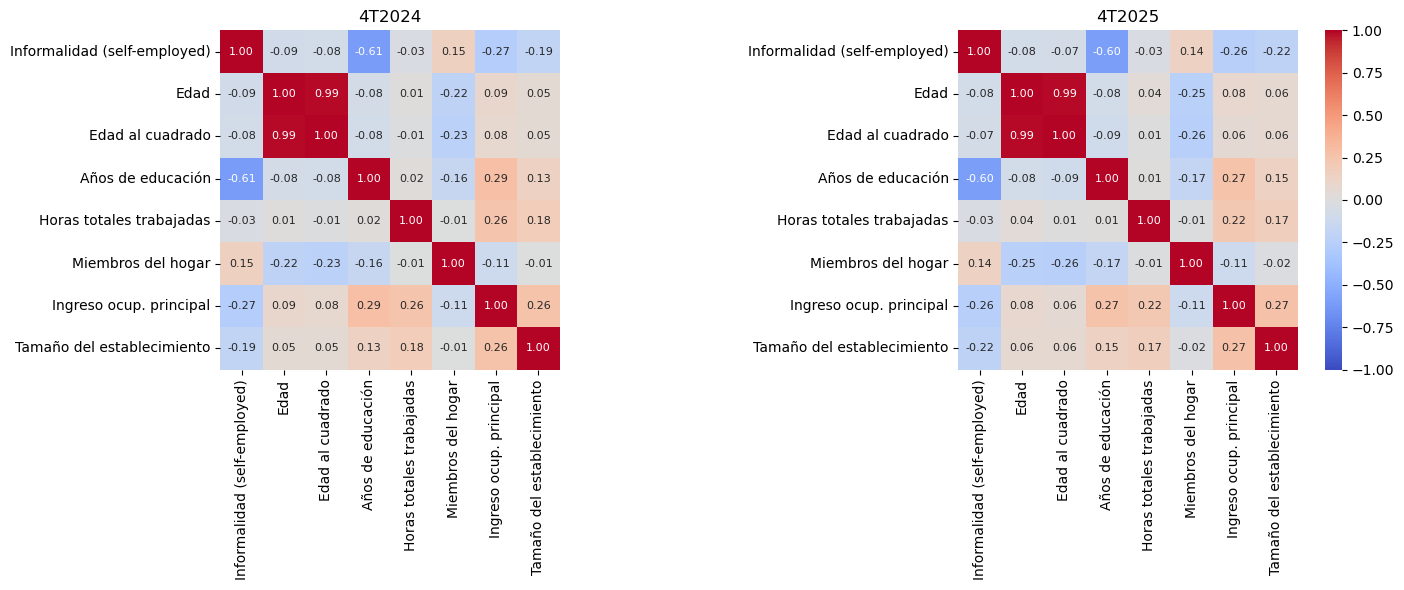

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables del inciso 3 (edad = CH06)
vars_corr = ['informal', 'CH06', 'edad2', 'educ', 'horastrab', 'nhogar', 'P21', 'PP04C']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, anio in zip(axes, [2024, 2025]):
    corr = self_emp.loc[self_emp['ANO4'] == anio, vars_corr].corr()
    corr.index = [etiquetas.get(v, v) for v in corr.index]
    corr.columns = [etiquetas.get(v, v) for v in corr.columns]

    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, square=True, ax=ax,
                cbar=(anio == 2025), annot_kws={'size': 8})
    ax.set_title(f'4T{anio}')

plt.tight_layout()
plt.show()

In [28]:
c24 = self_emp.loc[self_emp['ANO4']==2024, vars_corr].corr()
c25 = self_emp.loc[self_emp['ANO4']==2025, vars_corr].corr()

# Cambio de cada correlación con informal entre años
pd.DataFrame({'2024': c24['informal'], '2025': c25['informal']}).round(3)

,2024,2025
informal,1.000,1.000
CH06,-0.092,-0.085
edad2,-0.085,-0.072
educ,-0.611,-0.601
horastrab,-0.033,-0.034
nhogar,0.150,0.138
P21,-0.266,-0.256
PP04C,-0.189,-0.218


In [29]:
print(self_emp['CAT_OCUP'].value_counts().sort_index())

for cat, nombre in [(1,'Patrón'), (2,'Cuenta propia'), (4,'Fam. sin remun.')]:
    sub = self_emp[self_emp['CAT_OCUP']==cat].dropna(subset=['educ','informal'])
    if sub['informal'].nunique() > 1:
        r = sub[['educ','informal']].corr().iloc[0,1]
        print(f"{nombre:18} n={len(sub):5}  corr(educ, informal) = {r:.3f}")
    else:
        print(f"{nombre:18} n={len(sub):5}  informal constante")

CAT_OCUP
1    1478
2    9933
4     184
Name: count, dtype: int64
Patrón             n= 1411  corr(educ, informal) = -0.208
Cuenta propia      n= 9816  corr(educ, informal) = -0.674
Fam. sin remun.    n=  182  informal constante


La correlación entre años de educación e informalidad (-0,61) es la más alta de la
matriz, pero está en parte determinada por construcción: en la definición de Maurizio
& Monsalvo, un cuentapropista se considera formal si alcanzó el nivel universitario
completo. Al desagregar por categoría ocupacional, la correlación es -0,67 entre
cuentapropistas (85% de la muestra) y solo -0,21 entre patrones, cuyo criterio de
formalidad depende del tamaño del establecimiento. Esta advertencia debe tenerse
presente al interpretar los resultados de la Parte II.

Parte II.A - PCA

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Las 7 variables del enunciado (edad = CH06)
vars_pca = ['CH06', 'edad2', 'educ', 'horastrab', 'nhogar', 'P21', 'PP04C']

# PCA no admite faltantes: nos quedamos con los casos completos
datos = self_emp[vars_pca + ['informal']].dropna()

print("Casos completos:", len(datos), "de", len(self_emp))
print(datos['informal'].value_counts())

Casos completos: 8520 de 11595
informal
1.0    7027
0.0    1493
Name: count, dtype: int64
